<a href="https://colab.research.google.com/github/AdzrielNaufal/UAS_BDDM/blob/main/UAS_4619_BDDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [2]:
import pandas as pd # Importing the pandas library and aliasing it as 'pd'

hpsd = pd.read_csv('/content/drive/MyDrive/BDDM/high_popularity_spotify_data.csv')
hpsd

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.1220,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.000000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.1170,0.438,Billie Eilish,4,0.0358,...,0.060800,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.1590,0.372,Gracie Abrams,4,0.0368,...,0.000000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.3040,0.786,Sabrina Carpenter,4,0.0634,...,0.000000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.3550,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.000000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.422,124.357,0.573,latin,-7.621,0.1020,0.693,Libianca,5,0.0678,...,0.000013,5Hmh6N8oisrcuZKa8EY5dn,0,10,184791,0.5510,26b3oVLrRUaaybJulow9kz,afro-latin,audio_features,0oU30cCr8klmMsuOKHDLkh
1682,0.725,105.016,0.711,latin,-8.315,0.1100,0.530,Omah Lay,4,0.0941,...,0.129000,5NLjxx8nRy9ooUmgpOvfem,0,3,183057,0.4240,1wADwLSkYhrSmy4vdy6BRn,afro-latin,audio_features,0oU30cCr8klmMsuOKHDLkh
1683,0.809,99.005,0.724,latin,-5.022,0.0765,0.606,"Davido, FAVE",4,0.0929,...,0.000000,6lI21W76LD0S3vC55GrfSS,0,6,194040,0.1820,7vKXc90NT5WBm3UTT4iTVG,afro-latin,audio_features,0oU30cCr8klmMsuOKHDLkh
1684,0.642,83.389,0.463,latin,-4.474,0.0686,0.339,"Future, Drake, Tems",4,0.3400,...,0.000000,6tE9Dnp2zInFij4jKssysL,1,1,189893,0.3140,59nOXPmaKlBfGMDeOVGrIK,afro-latin,audio_features,0oU30cCr8klmMsuOKHDLkh


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

hpsd = pd.read_csv('/content/drive/MyDrive/BDDM/high_popularity_spotify_data.csv')
print(hpsd.head())
print(hpsd.info())
print(hpsd.describe())
print(hpsd.isnull().sum())

   energy    tempo  danceability playlist_genre  loudness  liveness  valence  \
0   0.592  157.969         0.521            pop    -7.777     0.122    0.535   
1   0.507  104.978         0.747            pop   -10.171     0.117    0.438   
2   0.808  108.548         0.554            pop    -4.169     0.159    0.372   
3   0.910  112.966         0.670            pop    -4.070     0.304    0.786   
4   0.783  149.027         0.777            pop    -4.477     0.355    0.939   

            track_artist  time_signature  speechiness  ...  instrumentalness  \
0  Lady Gaga, Bruno Mars               3       0.0304  ...            0.0000   
1          Billie Eilish               4       0.0358  ...            0.0608   
2          Gracie Abrams               4       0.0368  ...            0.0000   
3      Sabrina Carpenter               4       0.0634  ...            0.0000   
4       ROSÉ, Bruno Mars               4       0.2600  ...            0.0000   

           track_album_id mode key dur

In [4]:
import pandas as pd

# Hitung matriks korelasi, hanya untuk kolom numerik
numeric_hpsd = hpsd.select_dtypes(include=['number']) # Select only numeric columns
correlation_matrix = numeric_hpsd.corr()

# Tampilkan fitur yang berkorelasi dengan variabel target (misalnya, 'track_popularity')
target_corr = correlation_matrix['track_popularity'].sort_values(ascending=False)
print(target_corr)

track_popularity    1.000000
loudness            0.083132
tempo               0.016659
mode                0.014359
liveness            0.004202
key                 0.001024
danceability       -0.002220
valence            -0.006478
energy             -0.007536
acousticness       -0.016960
instrumentalness   -0.063107
duration_ms        -0.066444
time_signature     -0.114827
speechiness        -0.137957
Name: track_popularity, dtype: float64


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Misalkan 'track_popularity' adalah target
X = hpsd.drop(columns=['track_popularity'])
y = hpsd['track_popularity']

# Identify and encode categorical columns with LabelEncoder
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Pembagian data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Random Forest
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Mendapatkan pentingnya fitur
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feature_importance)

track_album_release_date    0.118066
playlist_id                 0.108210
playlist_name               0.074116
playlist_genre              0.069162
playlist_subgenre           0.066043
speechiness                 0.048754
duration_ms                 0.043193
loudness                    0.037946
track_artist                0.037502
track_album_id              0.037281
acousticness                0.036579
tempo                       0.035183
track_album_name            0.034902
danceability                0.033990
valence                     0.033401
liveness                    0.032627
track_name                  0.031227
energy                      0.027738
key                         0.020671
instrumentalness            0.018801
id                          0.009967
analysis_url                0.009952
track_href                  0.009591
uri                         0.009392
track_id                    0.008908
time_signature              0.003667
mode                        0.003130
t

In [6]:
from sklearn.feature_selection import RFE

# Menggunakan model Random Forest
selector = RFE(model, n_features_to_select=10)  # Misalnya memilih 10 fitur terbaik
selector = selector.fit(X_train, y_train)

# Menampilkan fitur yang terpilih
selected_features = X.columns[selector.support_]
print(selected_features)

Index(['playlist_genre', 'loudness', 'speechiness', 'playlist_name',
       'track_album_release_date', 'track_album_id', 'duration_ms',
       'acousticness', 'playlist_subgenre', 'playlist_id'],
      dtype='object')


In [7]:
from sklearn.feature_selection import mutual_info_regression

# Menghitung Mutual Information
mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_series)

track_album_release_date    0.243615
danceability                0.226745
track_artist                0.223131
track_album_name            0.215103
liveness                    0.213614
track_name                  0.210291
acousticness                0.200397
loudness                    0.200283
track_album_id              0.192549
playlist_id                 0.190577
track_id                    0.188240
uri                         0.187516
analysis_url                0.186842
id                          0.186623
track_href                  0.186237
playlist_name               0.185645
speechiness                 0.181432
duration_ms                 0.178630
energy                      0.175591
tempo                       0.162703
playlist_subgenre           0.151713
playlist_genre              0.136083
instrumentalness            0.132199
valence                     0.125091
key                         0.049287
type                        0.029731
time_signature              0.020504
m

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    1686 non-null   float64
 1   tempo                     1686 non-null   float64
 2   danceability              1686 non-null   float64
 3   playlist_genre            1686 non-null   object 
 4   loudness                  1686 non-null   float64
 5   liveness                  1686 non-null   float64
 6   valence                   1686 non-null   float64
 7   track_artist              1686 non-null   object 
 8   time_signature            1686 non-null   int64  
 9   speechiness               1686 non-null   float64
 10  track_popularity          1686 non-null   int64  
 11  track_href                1686 non-null   object 
 12  uri                       1686 non-null   object 
 13  track_album_name          1685 non-null   object 
 14  playlist

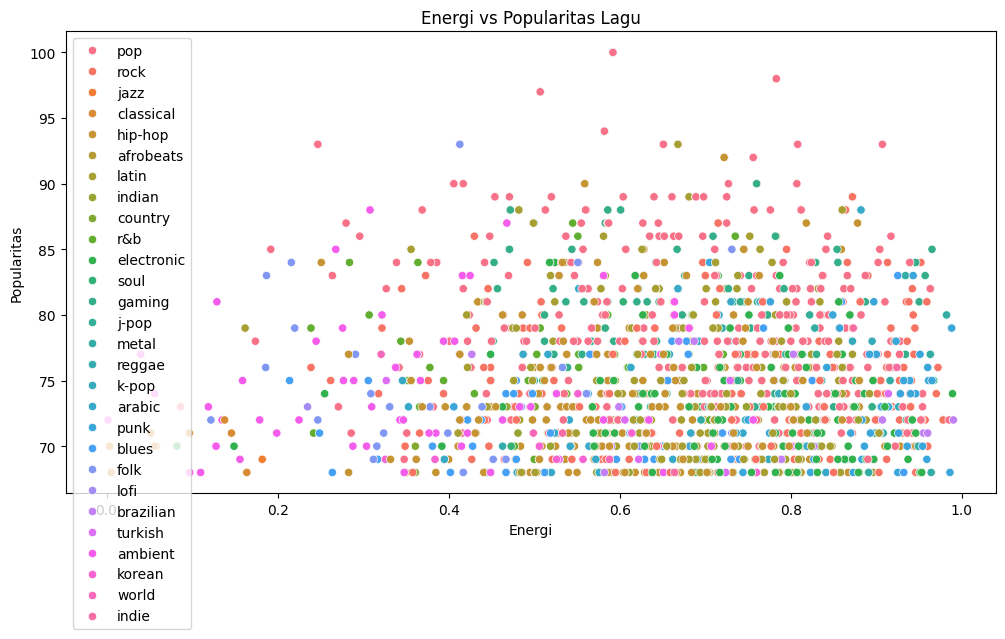

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset
hpsd = pd.read_csv('/content/drive/MyDrive/BDDM/high_popularity_spotify_data.csv')

# Menampilkan informasi dasar
print(hpsd.info())
print(hpsd.describe())

# Visualisasi karakteristik musik
plt.figure(figsize=(12, 6))
sns.scatterplot(data=hpsd, x='energy', y='track_popularity', hue='playlist_genre')
plt.title('Energi vs Popularitas Lagu')
plt.xlabel('Energi')
plt.ylabel('Popularitas')
plt.legend()
plt.show()

In [9]:
# Memisahkan fitur dan target
X = hpsd.drop(columns=['track_popularity', 'track_name', 'track_artist', 'playlist_name', 'track_id',
                       'track_href', 'uri', 'track_album_name', 'track_album_id', 'track_album_release_date'])
y = hpsd['track_popularity']

# Pembagian data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran set pelatihan dan pengujian
print(f'Ukuran set pelatihan: {X_train.shape[0]}')
print(f'Ukuran set pengujian: {X_test.shape[0]}')
print(f'Fitur pelatihan:\n{X_train.head()}')
print(f'Target pelatihan:\n{y_train.head()}')

Ukuran set pelatihan: 1348
Ukuran set pengujian: 338
Fitur pelatihan:
      energy    tempo  danceability playlist_genre  loudness  liveness  \
366    0.552   90.098         0.641            r&b    -5.423     0.148   
1204   0.859   65.043         0.728          blues    -5.237     0.111   
226    0.413  131.964         0.772        hip-hop    -8.194     0.111   
231    0.676  162.012         0.814        hip-hop    -4.670     0.119   
1061   0.872  184.115         0.466           rock    -3.344     0.121   

      valence  time_signature  speechiness  \
366     0.152               4       0.0283   
1204    0.535               4       0.1370   
226     0.211               4       0.0891   
231     0.312               4       0.2310   
1061    0.806               4       0.0336   

                                           analysis_url  instrumentalness  \
366   https://api.spotify.com/v1/audio-analysis/0mZ5...          0.000005   
1204  https://api.spotify.com/v1/audio-analysis/6epn..

In [21]:
for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Pembagian data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

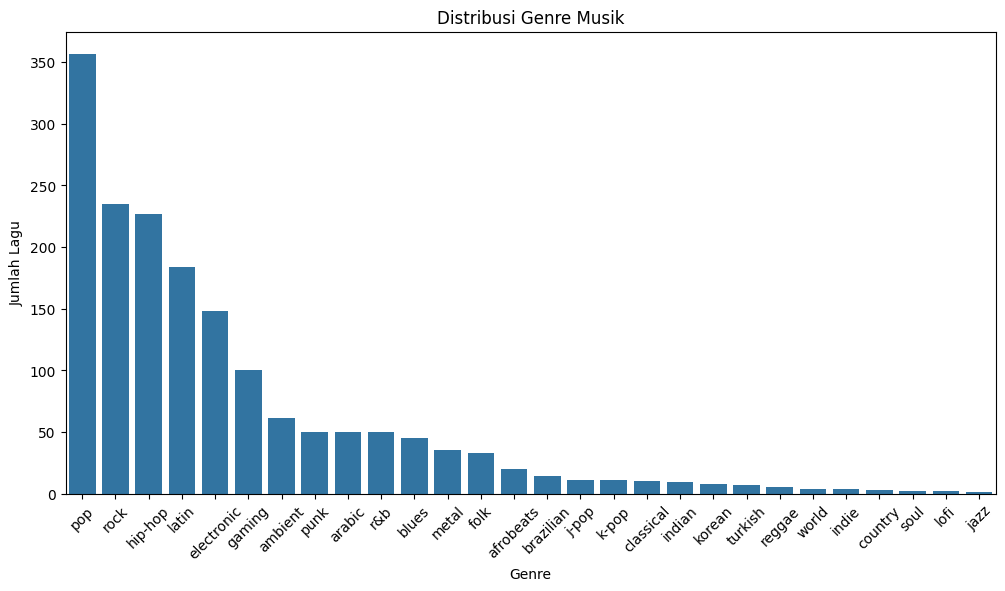

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=hpsd, x='playlist_genre', order=hpsd['playlist_genre'].value_counts().index)
plt.title('Distribusi Genre Musik')
plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Jumlah Lagu')
plt.show()

In [13]:
from sklearn.neighbors import NearestNeighbors

# Inisialisasi model KNN
knn = NearestNeighbors(n_neighbors=5)  # Menentukan jumlah rekomendasi
knn.fit(X)

# Fungsi untuk merekomendasikan lagu
def recommend_songs(input_features):
    distances, indices = knn.kneighbors([input_features])
    return hpsd.iloc[indices[0]]

# Contoh input untuk rekomendasi (menggunakan nilai rata-rata dari fitur)
input_features = X.mean()  # Misalnya, menggunakan rata-rata fitur sebagai input
recommended_songs = recommend_songs(input_features)

print("Rekomendasi Lagu:")
print(recommended_songs[['track_name', 'track_artist', 'track_popularity']])

Rekomendasi Lagu:
                                        track_name       track_artist  \
283                                        Soltera            Shakira   
1067                                          Ride  Twenty One Pilots   
88    Another One Bites The Dust - Remastered 2011              Queen   
645   Another One Bites The Dust - Remastered 2011              Queen   
1249                                  Saturday Sun          Vance Joy   

      track_popularity  
283                 86  
1067                80  
88                  71  
645                 71  
1249                69  


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [18]:
print(X_train.isnull().sum())  # Memeriksa nilai yang hilang
print(y_train.isnull().sum())

energy                      0
tempo                       0
danceability                0
playlist_genre              0
loudness                    0
liveness                    0
valence                     0
track_artist                0
time_signature              0
speechiness                 0
track_href                  0
uri                         0
track_album_name            1
playlist_name               0
analysis_url                0
track_id                    0
track_name                  0
track_album_release_date    0
instrumentalness            0
track_album_id              0
mode                        0
key                         0
duration_ms                 0
acousticness                0
id                          0
playlist_subgenre           0
type                        0
playlist_id                 0
dtype: int64
0


In [19]:
X_train.fillna(0, inplace=True)  # Mengisi dengan 0
y_train.fillna(y_train.mean(), inplace=True)  # Mengisi dengan rata-rata